Nombre: [Tu nombre aquí]

# Proyecto: Clasificación de Perros y Gatos con MobileNetV2

Entrenar un modelo con las clases:

- Gatos
- Perros

Al final guardará el modelo y las clases para usarlo en predicciones.

In [14]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


In [15]:
from PIL import Image
import os

def convertir_a_rgb(ruta):
    convertidas = 0
    errores = 0
    for clase in os.listdir(ruta):
        carpeta = os.path.join(ruta, clase)
        if not os.path.isdir(carpeta):
            continue
        for archivo in os.listdir(carpeta):
            ruta_img = os.path.join(carpeta, archivo)
            try:
                with Image.open(ruta_img) as img:
                    if img.mode != 'RGB':
                        print(f'Convirtiendo ({img.mode} → RGB): {archivo}')
                        img_rgb = img.convert('RGB')
                        img_rgb.save(ruta_img)
                        convertidas += 1
            except Exception as e:
                print(f'Eliminando corrupta: {ruta_img} → {e}')
                os.remove(ruta_img)
                errores += 1
    print(f'\nListo. Convertidas: {convertidas} | Eliminadas: {errores}')

convertir_a_rgb('C:\\Users\\HTS\\Desktop\\Proyecto_clasificador_mascotas\\dataset')


Convirtiendo (L → RGB): 2939.jpg
Convirtiendo (L → RGB): 5686.jpg
Convirtiendo (L → RGB): 7276.jpg
Convirtiendo (RGBA → RGB): 11285.jpg
Convirtiendo (L → RGB): 1773.jpg
Convirtiendo (L → RGB): 3823.jpg
Convirtiendo (RGBA → RGB): 7514.jpg

Listo. Convertidas: 7 | Eliminadas: 0


In [22]:
import tensorflow as tf
import os

def encontrar_imagenes_malas(ruta):
    eliminadas = 0
    for clase in os.listdir(ruta):
        carpeta = os.path.join(ruta, clase)
        if not os.path.isdir(carpeta):
            continue
        for archivo in os.listdir(carpeta):
            ruta_img = os.path.join(carpeta, archivo)
            try:
                raw = tf.io.read_file(ruta_img)
                tf.image.decode_image(raw, channels=3, expand_animations=False)
            except Exception as e:
                print(f'Eliminando: {ruta_img}')
                os.remove(ruta_img)
                eliminadas += 1
    print(f'\nListo. Eliminadas: {eliminadas}')

encontrar_imagenes_malas('C:\\Users\\HTS\\Desktop\\Proyecto_clasificador_mascotas\\dataset')

Eliminando: C:\Users\HTS\Desktop\Proyecto_clasificador_mascotas\dataset\Gatos\10404.jpg
Eliminando: C:\Users\HTS\Desktop\Proyecto_clasificador_mascotas\dataset\Gatos\4351.jpg
Eliminando: C:\Users\HTS\Desktop\Proyecto_clasificador_mascotas\dataset\Perros\11233.jpg
Eliminando: C:\Users\HTS\Desktop\Proyecto_clasificador_mascotas\dataset\Perros\11912.jpg
Eliminando: C:\Users\HTS\Desktop\Proyecto_clasificador_mascotas\dataset\Perros\2317.jpg
Eliminando: C:\Users\HTS\Desktop\Proyecto_clasificador_mascotas\dataset\Perros\2494.jpg
Eliminando: C:\Users\HTS\Desktop\Proyecto_clasificador_mascotas\dataset\Perros\9500.jpg

Listo. Eliminadas: 7


In [23]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Ruta del dataset local
DATA_DIR = 'C:\\Users\\HTS\\Desktop\\Proyecto_clasificador_mascotas\\dataset'

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
print('Clases detectadas: ', class_names)

Found 24931 files belonging to 2 classes.
Using 19945 files for training.
Found 24931 files belonging to 2 classes.
Using 4986 files for validation.
Clases detectadas:  ['Gatos', 'Perros']


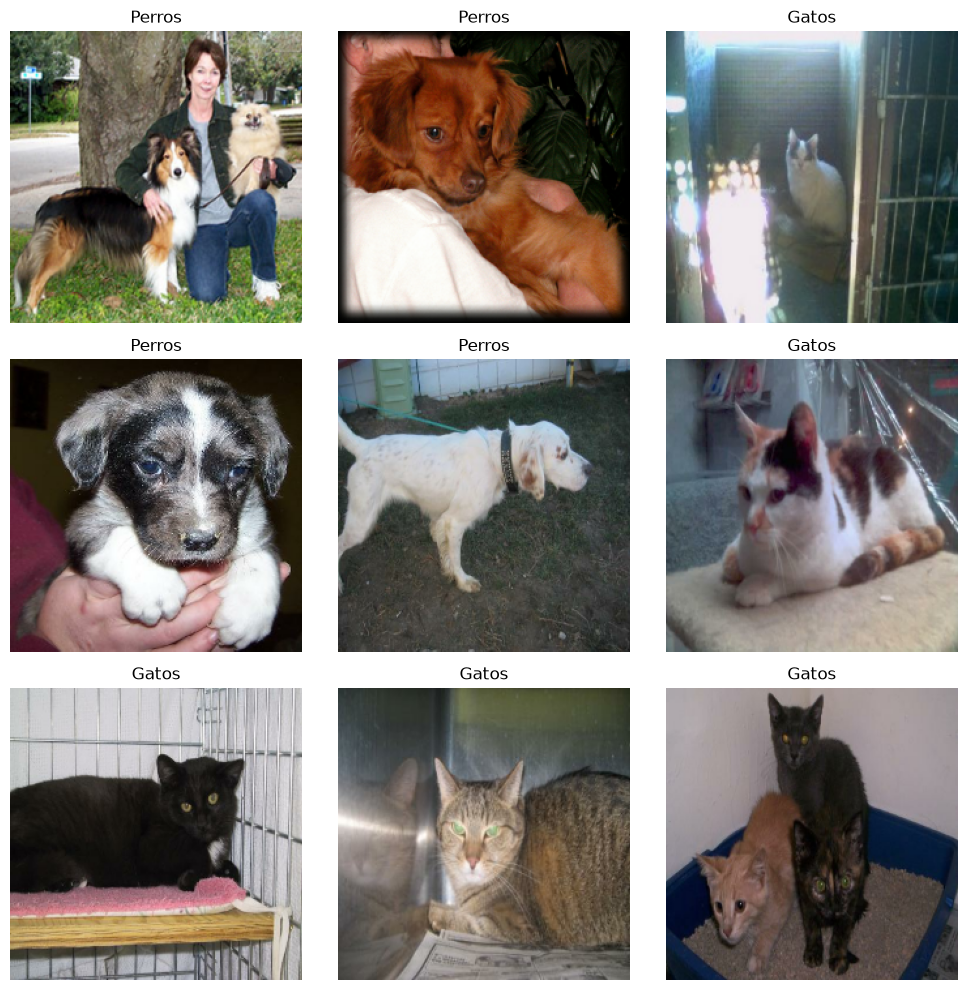

In [24]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.tight_layout()
plt.show()

Este fragmento de código prepara los conjuntos de datos de entrenamiento (train_ds) y validación (val_ds) para ser utilizados por un modelo MobileNetV2 en TensorFlow. Primero, AUTOTUNE = tf.data.AUTOTUNE permite que TensorFlow optimice automáticamente el uso de recursos al cargar los datos. Luego, preprocess_input aplica el preprocesamiento específico de MobileNetV2, transformando los valores de los píxeles de las imágenes al formato esperado por esta red neuronal. Con map(), cada imagen (x) se convierte al tipo float32 mediante tf.cast() y posteriormente se preprocesa, mientras que las etiquetas (y) permanecen sin cambios. Finalmente, prefetch(AUTOTUNE) carga los siguientes lotes de datos en segundo plano mientras el modelo está entrenando, mejorando el rendimiento y reduciendo los tiempos de espera durante el entrenamiento.

In [25]:
AUTOTUNE = tf.data.AUTOTUNE

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)).prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)).prefetch(AUTOTUNE)

# Crear un modelo de clasificación de imágenes basado en MobileNetV2 preentrenada en ImageNet.

- La red base se mantiene congelada para aprovechar sus características aprendidas, y se agregan nuevas capas para clasificar las imágenes en las categorías definidas.

- Finalmente, el modelo se compila usando el optimizador Adam y la métrica de precisión (accuracy) para su entrenamiento y evaluación.

In [26]:
# Crear el modelo MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Entrenar

Para probar rápido usa EPOCHS=1

In [27]:
EPOCHS = 1
callbacks = [
    # EarlyStopping detiene el entrenamiento cuando ve que ya no aprende
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        # Cuando con 2 consecutivas no aprende lo detiene
        patience=2,
        restore_best_weights=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

624/624 ━━━━━━━━━━━━━━━━━━━━ 151s 239ms/step - accuracy: 0.9786 - loss: 0.0608 - val_accuracy: 0.9898 - val_loss: 0.0294


In [28]:
loss, acc = model.evaluate(val_ds, verbose=0)
print(f'Loss {loss:.4f}')
print(f'Accuracy {acc:.4f}')

Loss 0.0294
Accuracy 0.9898


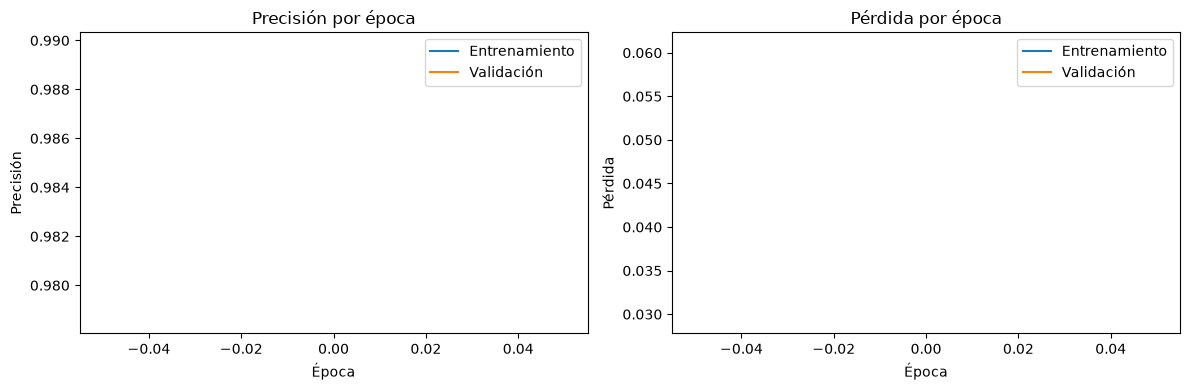

In [29]:
# Graficar precisión y pérdida
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Entrenamiento')
ax1.plot(history.history['val_accuracy'], label='Validación')
ax1.set_title('Precisión por época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Precisión')
ax1.legend()

ax2.plot(history.history['loss'], label='Entrenamiento')
ax2.plot(history.history['val_loss'], label='Validación')
ax2.set_title('Pérdida por época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Pérdida')
ax2.legend()

plt.tight_layout()
plt.show()

In [32]:
# Guardar el modelo
model.save('modelo_perros_gatos.h5')
# Guardar el modelo en formato .keras
model.save('modelo_perros_gatos.keras')

# Guardar las clases en un archivo JSON
with open('clases.json', 'w') as f:
    json.dump(class_names, f)

print('Modelo guardado como modelo_perros_gatos.h5')
print('Modelo guardado como modelo_perros_gatos.keras')
print('Clases guardadas como clases.json')

Modelo guardado como modelo_perros_gatos.h5
Modelo guardado como modelo_perros_gatos.keras
Clases guardadas como clases.json


# Realizar las pruebas

Buscar en Internet imágenes de perros y gatos, cargarlas en el proyecto y verificar qué tan bien clasifica las imágenes.

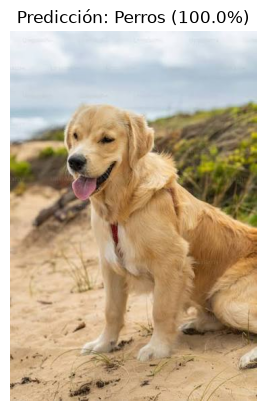

Resultado: Perros con 100.0% de confianza


In [33]:
def clasificar_imagen(ruta_imagen):
    img = tf.keras.utils.load_img(ruta_imagen, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = preprocess_input(tf.cast(img_array, tf.float32))
    img_array = tf.expand_dims(img_array, axis=0)

    prediccion = model.predict(img_array, verbose=0)
    clase = class_names[np.argmax(prediccion)]
    confianza = np.max(prediccion) * 100

    plt.imshow(tf.keras.utils.load_img(ruta_imagen))
    plt.title(f'Predicción: {clase} ({confianza:.1f}%)')
    plt.axis('off')
    plt.show()

    print(f'Resultado: {clase} con {confianza:.1f}% de confianza')


# Cambia la ruta por tu imagen de prueba
clasificar_imagen('prueba.jpg')